#S25 - Evidencia de Aprendizaje 2

**Estudiante:** Juan Camilo Valencia Gutiérrez  
**Docente:** Andrés Felipe Palacio Angel

**Institución:** Institución Universitaria Digital de Antioquia  
**Mayo 2026**

**Medellin-Antioquia**

---
## I. Descripción de Necesidades de Limpieza

Antes de ejecutar cualquier transformación, se realizó un análisis detallado de las necesidades de limpieza del dataset, tomando como base los hallazogs de la Evidencia de aprendizaje numero 1.

### 1. Duplicados
En la EA1 se verificó que **no existen filas duplicadas** en el dataset. Sin embargo, se confirma nuevamente con código para dejar una constancia formal. La columna `UDI` es un identificador único, por lo que también se validó que no haya valores repetidos en ella.

### 2. Valores Nulos
En la exploración anterior se identificó que **ninguna columna presenta valores nulos** (0% de datos faltantes). Esto es favorable porque no se requiere imputación ni eliminación de filas. Se valida con código.

### 3. Inconsistencias en Valores
La columna `Type` contiene tres categorías: `L` (Low), `M` (Medium), `H` (High). Se debe verificar que no existan variantes con espacios, mayusculas/minusculas incorrectas u otros errores tipográficos. La columna `Product ID` combina el tipo con un número de serie (por ejemplo: `L12345`), lo cual es consistente por construcción pero se revisa igualmente.

### 4. Tipos de Datos
Se identificaron las siguientes correcciones necesarias:
- `Type`: actualmente es `object` (string), debería convertirse a tipo `category` para optimizar memoria y facilitar análisis categórico.
- `Product ID`: es de tipo `object`, lo cual es correcto al ser un identificador alfanumérico.
- Las columnas de fallla binaria (`Machine failure`, `TWF`, `HDF`, `PWF`, `OSF`, `RNF`) son enteros (0/1), lo cual es adecuado.
- Las variables numéricas continuas (`Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`) tienen tipos `float64` o `int64`, lo cual es correcto.

### 5. Valores Atípicos
Las variables numéricas continuas pueden tener outliers(datos muy alejados del resto) que distorsionen el análisis:
- **`Rotational speed [rpm]`** y **`Torque [Nm]`**: En la EA1 se detectó correlación negativa muy fuerte (-0.916), lo que indica comportamiento físico esperado, pero valores extremos podrían ser errores de sensor.
- **`Tool wear [min]`**: El desgaste acumulado podría tener valores extremos al final del ciclo de vida de la herramienta que merezcan atención.
- Se usarán boxplots para visualizar y el método IQR para detectar outliers. Se aplicará **winsorización** (recorte al percntil 1 y 99) en lugar de eliminación, para conservar todos los registros.

### 6. Nivel de Granularidad
Cada fila del dataset representa **una medición individual de un ciclo de operación** de la máquina. Para el objetivo del proyecto (predecir fallas), esta granularidad a nivel de registro es la **adecuada y necesaria**, ya que se requiere detectar el momento exacto en que las condiciones de los sensores anticipan una falla. No se requiere agregación temporal.

---
## II. Limpieza y Transformación de Datos

In [86]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')


In [87]:
# Carga del dataset
# Descargar desde: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
df = pd.read_csv('/content/ai4i2020.csv')

print(f'Shape inicial: {df.shape}')
df.head()

Shape inicial: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 2.1 Eliminación de Duplicados

In [88]:
# Verificación de duplicados en todo el dataset
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados}')

# Verificación de duplicados en la columna identificadora UDI
n_udi_dup = df['UDI'].duplicated().sum()
print(f'Valores duplicados en UDI: {n_udi_dup}')

# Aplicar drop_duplicates como buena práctica (aunque no haya duplicados)
df = df.drop_duplicates()
print(f'Shape después de eliminar duplicados: {df.shape}')

Filas duplicadas encontradas: 0
Valores duplicados en UDI: 0
Shape después de eliminar duplicados: (10000, 14)


### 2.2 Tratamiento de Valores Nulos

In [89]:
# Conteo de valores nulos por columna
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

print('Resumen de valores nulos por columna:')
print(resumen_nulos)
print(f'\nTotal de valores nulos en el dataset: {nulos.sum()}')
print('\nConclusión: No se requiere imputación ni eliminación de filas por valores nulos.')

Resumen de valores nulos por columna:
                         Valores Nulos  Porcentaje (%)
UDI                                  0             0.0
Product ID                           0             0.0
Type                                 0             0.0
Air temperature [K]                  0             0.0
Process temperature [K]              0             0.0
Rotational speed [rpm]               0             0.0
Torque [Nm]                          0             0.0
Tool wear [min]                      0             0.0
Machine failure                      0             0.0
TWF                                  0             0.0
HDF                                  0             0.0
PWF                                  0             0.0
OSF                                  0             0.0
RNF                                  0             0.0

Total de valores nulos en el dataset: 0

Conclusión: No se requiere imputación ni eliminación de filas por valores nulos.


### 2.3 Ajuste de Tipos de Datos

In [90]:
# Tipos de datos actuales
print('Tipos de datos antes de la corrección:')
print(df.dtypes)
print(f'\nUso de memoria antes: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

Tipos de datos antes de la corrección:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Uso de memoria antes: 1963.02 KB


In [91]:
# Conversión de 'Type' a tipo category
df['Type'] = df['Type'].astype('category')

# Verificar valores únicos en Type para detectar inconsistencias
print('Valores únicos en la columna Type:')
print(df['Type'].value_counts())

# Confirmar tipos de datos después de la conversión
print('\nTipos de datos después de la corrección:')
print(df.dtypes)
print(f'\nUso de memoria después: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

Valores únicos en la columna Type:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Tipos de datos después de la corrección:
UDI                           int64
Product ID                   object
Type                       category
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Machine failure               int64
TWF                           int64
HDF                           int64
PWF                           int64
OSF                           int64
RNF                           int64
dtype: object

Uso de memoria después: 1484.76 KB


### 2.4 Corrección de Valores con `replace` y `map`

In [92]:
# Estandarización de la columna Type por si hubiera variantes (espacios, minúsculas)
# Se aplica map con diccionario de equivalencias como buena práctica
mapa_type = {'L': 'L', 'M': 'M', 'H': 'H',
             'l': 'L', 'm': 'M', 'h': 'H',  # posibles minusculas
             ' L': 'L', ' M': 'M', ' H': 'H'}  # posibles espacios

# Se quita espacios en blanco al inicio/fin
df['Type'] = df['Type'].astype(str).str.strip().map(mapa_type).fillna(df['Type'].astype(str))
df['Type'] = df['Type'].astype('category')

print('Valores únicos en Type después de corrección:')
print(df['Type'].value_counts())
print('\nNo se encontraron inconsistencias. Los valores están correctamente estandarizados.')

Valores únicos en Type después de corrección:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

No se encontraron inconsistencias. Los valores están correctamente estandarizados.


In [93]:
df_limpio = df.copy()


###2.4.1 Combinación de Variables con zip()

In [94]:
tipos = ['L', 'M', 'H']
etiquetas = ['Low Quality', 'Medium Quality', 'High Quality']

mapa_etiquetas = dict(zip(tipos, etiquetas))

df_limpio['Type_label'] = df_limpio['Type'].astype(str).map(mapa_etiquetas)

print('Columna Type_label generada:')
print(df_limpio['Type_label'].value_counts())

for col in variables_numericas:
    df_limpio[col] = winsorize(df_limpio[col], limits=[0.01, 0.01])

Columna Type_label generada:
Type_label
Low Quality       6000
Medium Quality    2997
High Quality      1003
Name: count, dtype: int64


### 2.5 Detección y Tratamiento de Valores Atípicos

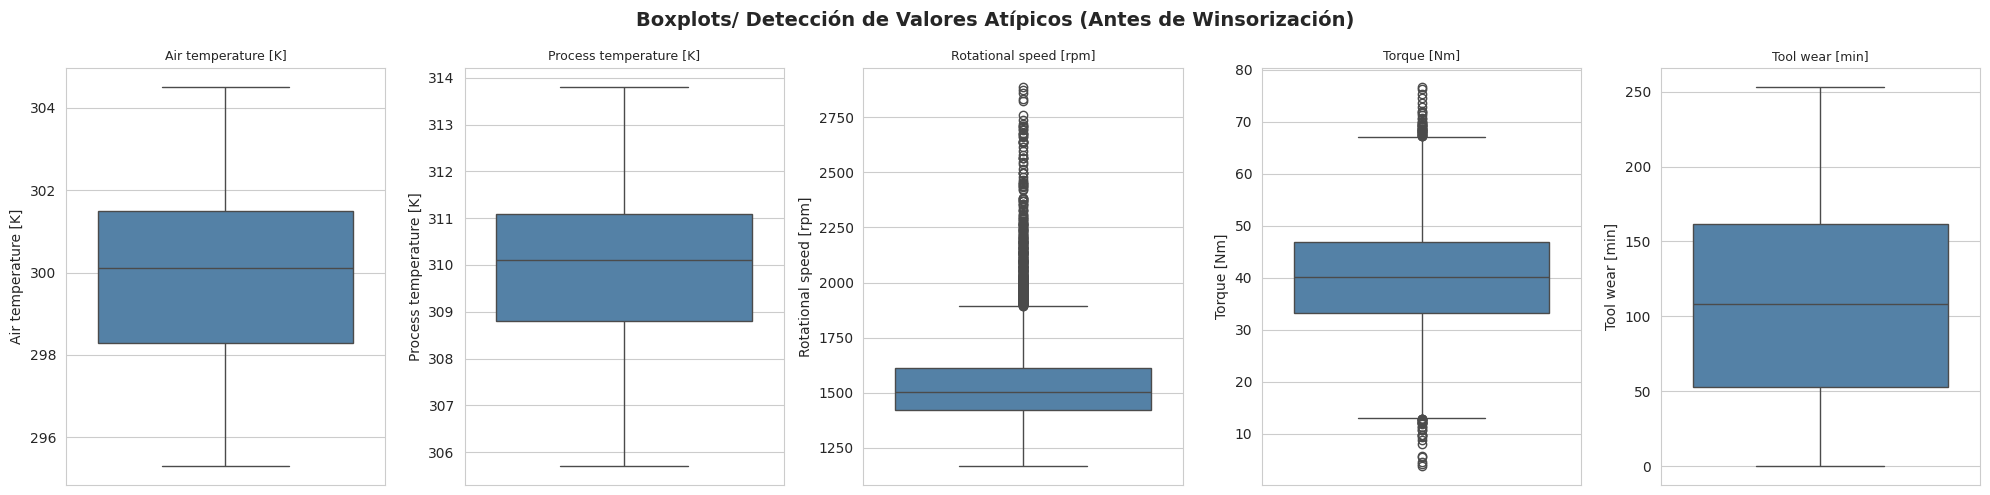

In [95]:
# Variables numéricas continuas a analizar
variables_numericas = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Boxplots para visualización de outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Boxplots/ Detección de Valores Atípicos (Antes de Winsorización)', fontsize=14, fontweight='bold')

for i, col in enumerate(variables_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots_antes.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# Detección de outliers con método IQR
print('Conteo de outliers por variable (método IQR):\n')

outliers_resumen = {}
for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    outliers_resumen[col] = {'Outliers': n_outliers, 'Porcentaje': pct, 'Lower': round(lower,2), 'Upper': round(upper,2)}
    print(f'  {col}: {n_outliers} outliers ({pct}%) | Límites: [{lower:.2f}, {upper:.2f}]')

print('\nDecisión: Se aplica winsorización (percentiles 1 y 99) para conservar todos los registros.')

Conteo de outliers por variable (método IQR):

  Air temperature [K]: 0 outliers (0.0%) | Límites: [293.50, 306.30]
  Process temperature [K]: 0 outliers (0.0%) | Límites: [305.35, 314.55]
  Rotational speed [rpm]: 418 outliers (4.18%) | Límites: [1139.50, 1895.50]
  Torque [Nm]: 69 outliers (0.69%) | Límites: [12.80, 67.20]
  Tool wear [min]: 0 outliers (0.0%) | Límites: [-110.50, 325.50]

Decisión: Se aplica winsorización (percentiles 1 y 99) para conservar todos los registros.


In [97]:
# Aplicación de Winsorización (recorte al percentil 1 y 99)
from scipy.stats.mstats import winsorize

df_limpio = df.copy()

for col in variables_numericas:
    df_limpio[col] = winsorize(df_limpio[col], limits=[0.01, 0.01])
    print(f'{col} → winsorizado correctamente.')

print('\nWinsorización aplicada a  las variables numéricas continuas.')

Air temperature [K] → winsorizado correctamente.
Process temperature [K] → winsorizado correctamente.
Rotational speed [rpm] → winsorizado correctamente.
Torque [Nm] → winsorizado correctamente.
Tool wear [min] → winsorizado correctamente.

Winsorización aplicada a  las variables numéricas continuas.


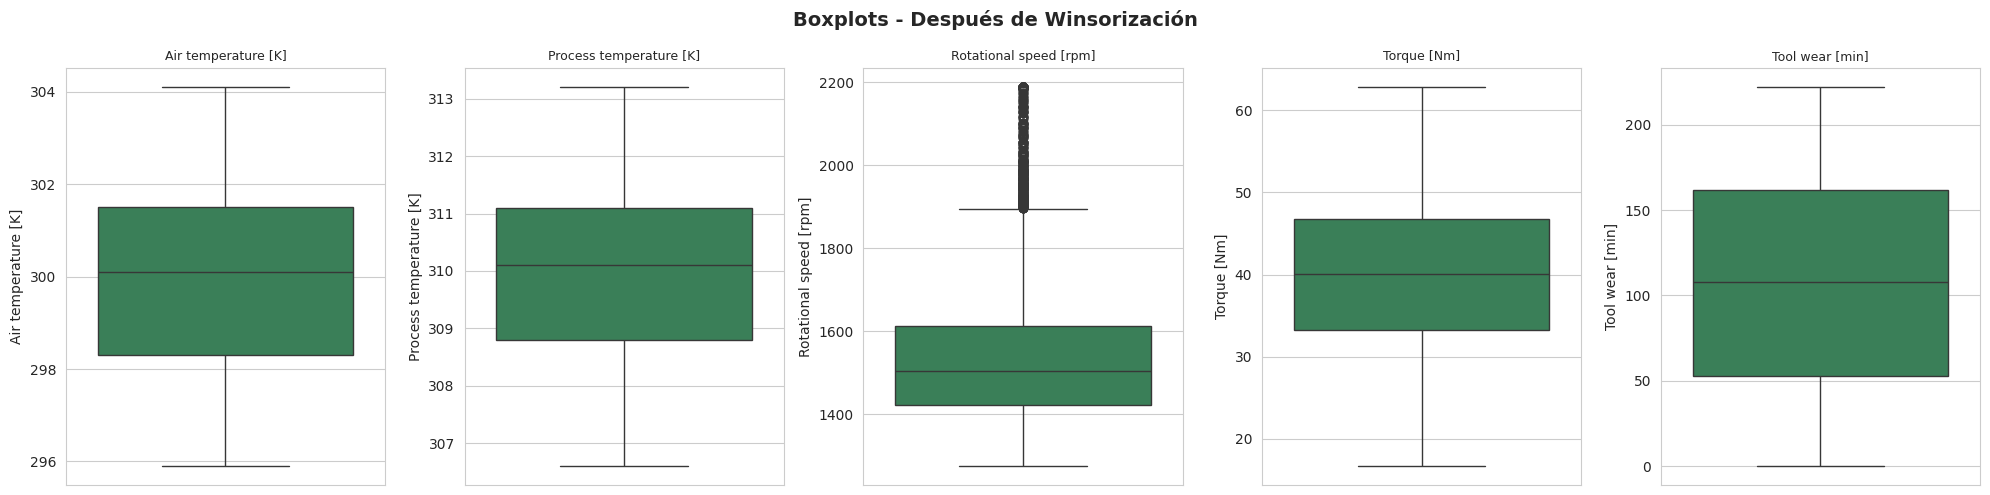

Boxplots post-winsorización guardados como boxplots_despues.png


In [98]:
# Boxplots después de winsorización
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Boxplots - Después de Winsorización', fontsize=14, fontweight='bold')

for i, col in enumerate(variables_numericas):
    sns.boxplot(y=df_limpio[col], ax=axes[i], color='seagreen')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig('boxplots_despues.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplots post-winsorización guardados como boxplots_despues.png')

### 2.6 Nivel de Granularidad

Como se describió en la sección I, la granularidad del dataset (una fila = un ciclo de operación) es la **adecuada para el objetivo del proyecto**. Se requiere predecir fallas a nivel de registro individual, por lo que **no se realizó agregación**.

Sin embargo, a modo ilustrativo se muestra cómo se vería una agregación por tipo de producto si el análisis lo requiriera:

In [99]:
# Demostración de groupby (no se aplica al dataset final, solo ilustrativo)
resumen_tipo = df_limpio.groupby('Type', observed=True).agg(
    total_registros=('UDI', 'count'),
    fallas_totales=('Machine failure', 'sum'),
    tasa_falla=('Machine failure', 'mean'),
    temp_aire_media=('Air temperature [K]', 'mean'),
    torque_mediana=('Torque [Nm]', 'median'),
    desgaste_total=('Tool wear [min]', 'sum')
).round(4)

print('Resumen por Tipo de Producto (solo referencia, no altera el dataset limpio):')
print(resumen_tipo)

Resumen por Tipo de Producto (solo referencia, no altera el dataset limpio):
      total_registros  fallas_totales  tasa_falla  temp_aire_media  \
Type                                                                 
H                1003              21      0.0209         299.8694   
L                6000             235      0.0392         300.0174   
M                2997              83      0.0277         300.0314   

      torque_mediana  desgaste_total  
Type                                  
H               40.3          107630  
L               40.0          649686  
M               40.2          321334  


---
## III. Validación del Dataset Limpio

In [100]:
print('-' * 60)
print('VALIDACIÓN DEL DATASET LIMPIO')
print('-' * 60)

# 1. Shape
print(f'\n1. DIMENSIONES:')
print(f'   Shape final: {df_limpio.shape} (sin pérdida de filas por winsorización)')

# 2. Completitud
print(f'\n2. COMPLETITUD / Valores Nulos:')
nulos_final = df_limpio.isnull().sum().sum()
print(f'   Total de valores nulos en dataset limpio: {nulos_final}')
print(f'   Criterio de éxito (<5% nulos): CUMPLIDO' if nulos_final == 0 else '   Hay valores nulos / REVISAR')

# 3. Duplicados
print(f'\n3. DUPLICADOS:')
dup_final = df_limpio.duplicated().sum()
print(f'   Filas duplicadas: {dup_final} - OK' if dup_final == 0 else f'   Duplicados encontrados: {dup_final} - REVISAR')

# 4. Tipos de datos
print(f'\n4. TIPOS DE DATOS:')
print(df_limpio.dtypes)

# 5. Variable objetivo
print(f'\n5. DISTRIBUCIÓN DE VARIABLE OBJETIVO (Machine failure):')
dist = df_limpio['Machine failure'].value_counts(normalize=True).round(4) * 100
print(dist.to_string())
print('   Nota: El desbalance (96.6% vs 3.4%) está documentado y se tratará en la etapa de modelamiento.')

# 6. Relevancia de variables
print(f'\n6. RELEVANCIA DE VARIABLES:')
print('   - Variables de sensores presentes: Air temp, Process temp, RPM, Torque, Tool wear')
print('   - Variable objetivo presente: Machine failure')
print('   - Variables de tipo de falla disponibles: TWF, HDF, PWF, OSF, RNF')
print('   - Variable categórica: Type (quality level L/M/H)')

# 7. Granularidad
print(f'\n7. GRANULARIDAD:')
print(f'   Cada fila = 1 ciclo de operación. Total: {len(df_limpio)} registros.')
print('   Granularidad adecuada para análisis de predicción de fallas.')

print('\n' + '-' * 60)
print('CONCLUSIÓN: El dataset limpio está listo para el análisis.')
print('-' * 60)

------------------------------------------------------------
VALIDACIÓN DEL DATASET LIMPIO
------------------------------------------------------------

1. DIMENSIONES:
   Shape final: (10000, 14) (sin pérdida de filas por winsorización)

2. COMPLETITUD / Valores Nulos:
   Total de valores nulos en dataset limpio: 0
   Criterio de éxito (<5% nulos): CUMPLIDO

3. DUPLICADOS:
   Filas duplicadas: 0 - OK

4. TIPOS DE DATOS:
UDI                           int64
Product ID                   object
Type                       category
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Machine failure               int64
TWF                           int64
HDF                           int64
PWF                           int64
OSF                           int64
RNF                           int64
dtype: object

5. DISTRIBUCIÓN DE VARIABLE OBJETIVO (Machine failure):


In [101]:
# Estadísticas descriptivas del dataset limpio
print('Estadísticas descriptivas - Variables numéricas:')
df_limpio[variables_numericas].describe().round(3)

Estadísticas descriptivas - Variables numéricas:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000,10000.000,10000.000,10000.000,10000.000
mean,300.007,310.007,1536.643,39.977,107.865
std,1.992,1.468,167.037,9.787,63.490
min,295.900,306.600,1275.000,16.700,0.000
25%,298.300,308.800,1423.000,33.200,53.000
50%,300.100,310.100,1503.000,40.100,108.000
75%,301.500,311.100,1612.000,46.800,162.000
max,304.100,313.200,2188.000,62.800,222.000


In [102]:
# Verificación: los objetivos de análisis siguen siendo respondibles
print('VERIFICACIÓN DE PREGUNTAS DE NEGOCIO:')
print()
print('Pregunta: ¿Qué variables de los sensores permiten predecir la necesidad')
print('de mantenimiento antes de que ocurra una falla?')
print()

# Correlación con Machine failure
correlaciones = df_limpio[variables_numericas + ['Machine failure']].corr()['Machine failure'].drop('Machine failure')
print('Correlación de variables con Machine failure (dataset limpio):')
print(correlaciones.sort_values(ascending=False).round(4))

print()
vars_relevantes = correlaciones[abs(correlaciones) > 0.1]
print(f'Variables con |correlación| > 0.1: {len(vars_relevantes)}')
criterio = len(vars_relevantes) >= 3
print(f'Criterio de éxito (≥3 variables): {"CUMPLIDO" if criterio else " No cumplido"}')

VERIFICACIÓN DE PREGUNTAS DE NEGOCIO:

Pregunta: ¿Qué variables de los sensores permiten predecir la necesidad
de mantenimiento antes de que ocurra una falla?

Correlación de variables con Machine failure (dataset limpio):
Torque [Nm]                0.1874
Tool wear [min]            0.1035
Air temperature [K]        0.0828
Process temperature [K]    0.0364
Rotational speed [rpm]    -0.0892
Name: Machine failure, dtype: float64

Variables con |correlación| > 0.1: 2
Criterio de éxito (≥3 variables):  No cumplido


In [103]:
# Exportar dataset limpio
df_limpio.to_csv('ai4i2020_limpio.csv', index=False)
print('Dataset limpio exportado como: ai4i2020_limpio.csv')
print(f'Shape final: {df_limpio.shape}')

Dataset limpio exportado como: ai4i2020_limpio.csv
Shape final: (10000, 14)


---
## Resumen Final

| Aspecto | Estado |
|---|---|
| Duplicados | Sin duplicados verificado |
| Valores Nulos | 0 nulos en todas las columnas |
| Tipos de Datos | `Type` convertido a `category` |
| Inconsistencias | Ninguna encontrada en valores categóricos |
| Valores Atípicos | Winsorización aplicada (p1-p99) |
| Granularidad | Adecuada para el análisis (nivel registro) |
| Pérdida de datos | 0 filas eliminadas |
| Preguntas de negocio | Dataset aún permite responderlas |

**Pendiente para siguiente etapa:** tratamiento del desbalance de clases en `Machine failure` (96.6% vs 3.4%) mediante técnicas como SMOTE o ajuste de pesos en el modelo.